In [ ]:
!pip install transformers datasets accelerate peft bitsandbytes sentencepiece

In [ ]:
import pandas as pd
# Load the dataset
#df = pd.read_csv('combined_data.csv')/content/combined_data.csv
df = pd.read_csv('/content/drive/MyDrive/combined_data.csv')

In [ ]:
from datasets import Dataset

# Rename columns (adjust based on dataset format)
df = df.rename(columns={"formatted_article": "document", "nepali_summary": "summary"})

# Convert to Hugging Face dataset format
dataset = Dataset.from_pandas(df)

# Split dataset
dataset = dataset.train_test_split(test_size=0.1)

train_data = dataset["train"]
val_data = dataset["test"]

print(train_data[0])  # Verify the format


{'document': 'चितवनको भरतपुर महानगरपालिकाको प्रमुखपदको मतगणनामा नेकपा (एमाले)का विजय सुवेदीले अग्रता कायम राखेका छन् । १० हजार ६ ०४ मतको गणनामा सुवेदीले नेकपा (माओवादी केन्द्र) की रेणु दाहाललाई १४ मतको झिनो अन्तरले पछि पारेका थिए । सुवेदीले तीन हजार ६६७ मत प्राप्त गरेका छन् भने दाहाल तीन हजार ६५३ मतका साथ पछि परेका छन् ।\xa0 स्वतन्त्र उम्मेदवार जगन्नाथ पौडेलले पनि आफ्नो मत संख्या बढाइरहेका छन् । पौडेलले हालसम्म एक हजार ४१३ मत प्राप्त गरेका छन् । त्यस्तै उपमेयरमा नेपाली काँग्रेसका चित्रसेन अधिकारीले चार हजार १५० मत प्राप्त गरेका छन् । उहाँका निकटतम प्रतिद्वन्द्वी राप्रपाका हिमाल गुरुङले दुई हजार ८८६ मत प्राप्त गर्नुभएको छ ।', 'summary': 'चितवनको भरतपुर महानगरपालिकाको प्रमुखमा नेकपा (एमाले)का विजय सुवेदीले तीन हजार ६६७ मत प्राप्त गरी अग्रता कायम गर्नुभएको छ भने रेणु दाहालले १४ मतले पछि पर्नुभएको छ । स्वतन्त्र उम्मेदवार जगन्नाथ पौडेलले पनि मत वृद्धि गरेका छन् भने उपमेयरमा नेपाली काँग्रेसका चित्रसेन अधिकारीले चार हजार १५० मत प्राप्त गरेका छन् ।'}


In [ ]:
from transformers import MBartForConditionalGeneration, MBart50TokenizerFast

model_name = "facebook/mbart-large-50"  # Multilingual mBART
tokenizer = MBart50TokenizerFast.from_pretrained(model_name)

# Set language token for Nepali
tokenizer.src_lang = "ne_NP"
tokenizer.tgt_lang = "ne_NP"


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
max_input_length = 512
max_target_length = 128

def preprocess_function(examples):
    inputs = tokenizer(examples["document"], max_length=max_input_length, truncation=True)
    targets = tokenizer(examples["summary"], max_length=max_target_length, truncation=True)

    return {
        "input_ids": inputs["input_ids"],
        "attention_mask": inputs["attention_mask"],
        "labels": targets["input_ids"],
    }

tokenized_datasets = dataset.map(preprocess_function, batched=True)


Map:   0%|          | 0/4543 [00:00<?, ? examples/s]

Map:   0%|          | 0/505 [00:00<?, ? examples/s]

In [ ]:
from peft import LoraConfig, get_peft_model
import torch

model = MBartForConditionalGeneration.from_pretrained(model_name)

# Define LoRA configuration
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],  # Apply LoRA to attention layers
    lora_dropout=0.1,
    bias="none",
    task_type="SEQ_2_SEQ_LM",
)

# Apply LoRA to the model
model = get_peft_model(model, lora_config)
model.to("cuda")  # Move to GPU


PeftModelForSeq2SeqLM(
  (base_model): LoraModel(
    (model): MBartForConditionalGeneration(
      (model): MBartModel(
        (shared): MBartScaledWordEmbedding(250054, 1024, padding_idx=1)
        (encoder): MBartEncoder(
          (embed_tokens): MBartScaledWordEmbedding(250054, 1024, padding_idx=1)
          (embed_positions): MBartLearnedPositionalEmbedding(1026, 1024)
          (layers): ModuleList(
            (0-11): 12 x MBartEncoderLayer(
              (self_attn): MBartSdpaAttention(
                (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
                (v_proj): lora.Linear(
                  (base_layer): Linear(in_features=1024, out_features=1024, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=1024, out_features=16, bias=False)
                  )
                  (

In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorForSeq2Seq

training_args = TrainingArguments(
    output_dir="./mbart-lora-nepali",
    eval_strategy="epoch",  # Fixed this line
    save_strategy="epoch",
    learning_rate=5e-4,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    weight_decay=0.01,
    fp16=True,  # Enable mixed precision for faster training
    push_to_hub=False,
)


In [ ]:
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,  # Ensure this is included
)


In [ ]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: suprishmamaharjan44284046 (suprishmamaharjan44284046-khec) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Epoch,Training Loss,Validation Loss
1,1.511600,1.737427
2,1.410800,1.352933
3,1.336000,1.339783


TrainOutput(global_step=3408, training_loss=1.6849315446307402, metrics={'train_runtime': 859.2271, 'train_samples_per_second': 15.862, 'train_steps_per_second': 3.966, 'total_flos': 9053056773242880.0, 'train_loss': 1.6849315446307402, 'epoch': 3.0})

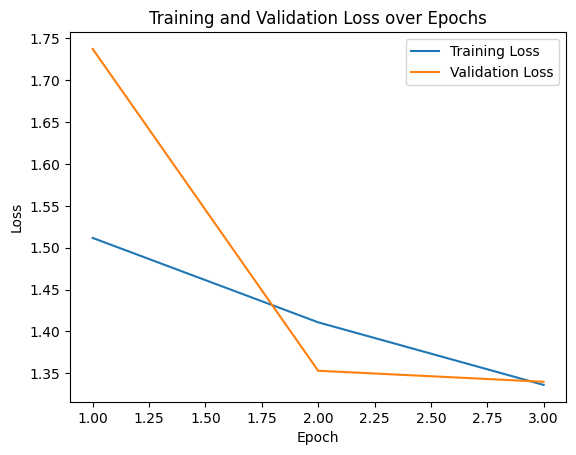

In [ ]:
import matplotlib.pyplot as plt

# Epochs, Training Loss, and Validation Loss data
epochs = [1, 2, 3]
training_loss = [1.511600, 1.410800, 1.336000]
validation_loss = [1.737427, 1.352933, 1.339783]

# Plotting the graph
plt.plot(epochs, training_loss, label='Training Loss')
plt.plot(epochs, validation_loss, label='Validation Loss')

# Adding labels and title
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')

# Adding legend
plt.legend()

# Displaying the graph
plt.show()

In [ ]:
def generate_summary(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to("cuda") for k, v in inputs.items()}

    summary_ids = model.generate(**inputs, max_length=128, num_beams=4)
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

# Test with a sample article
sample_text = dataset["test"][0]["document"]
print("Generated Summary:", generate_summary(sample_text))


Generated Summary: नेपाली राष्ट्रिय फुटबल टोलीका पूर्वकप्तान किरण चेम्जोङले आफ्नी प्रेमिका कञ्चन निरौलासँग विवाह गरेका छन् । माल्दिभ्समा जारी धिवेही प्रिमियर लिगको फाइनल खेलका क्रममा उनीहरुले इन्गेजमेन्ट गरेका थिए ।


In [ ]:
model.save_pretrained("/content/drive/MyDrive/mbart-lora-nepali(epo3)")
tokenizer.save_pretrained("/content/drive/MyDrive/mbart-lora-nepali(epo3)")


('/content/drive/MyDrive/mbart-lora-nepali(epo3)/tokenizer_config.json',
 '/content/drive/MyDrive/mbart-lora-nepali(epo3)/special_tokens_map.json',
 '/content/drive/MyDrive/mbart-lora-nepali(epo3)/sentencepiece.bpe.model',
 '/content/drive/MyDrive/mbart-lora-nepali(epo3)/added_tokens.json',
 '/content/drive/MyDrive/mbart-lora-nepali(epo3)/tokenizer.json')